In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from appF_diagnostic import *

In [ ]:
DEVICE = 'cuda'
n = 512
aspect_ratio = 4
# spectrum = torch.cat((
#     torch.logspace(-0.01, -2, steps=16, dtype=torch.float64, device=DEVICE),
#     torch.zeros(n - 16, dtype=torch.float64, device=DEVICE),
# ))
spectrum = torch.logspace(-0.01, -8, steps=n, dtype=torch.float64, device=DEVICE)
assert torch.all(spectrum[:-1] >= spectrum[1:]), "spectrum must be decreasing"
G = spectrum2matrix(spectrum, aspect_ratio)
# G = torch.diag(spectrum)

PE = PolarExpressDiagnostic(
    coeffs_name="ns3",
    steps=20,
    restarts=[],
    sym_mm_name="avg",
    ambient_dtype=torch.float64,
    xxt_dtype=torch.float16,
    do_diagnostics=True,
)
out, diagnostics = PE(G)
df = pd.DataFrame(diagnostics)
# since Z and Q are decreasing functions of the corresponding singular value of X_0, flip them for plotting purposes
df['Z_eigvals'] = df['Z_eigvals'].apply(np.flip)
df['Q_eigvals'] = df['Q_eigvals'].apply(np.flip)

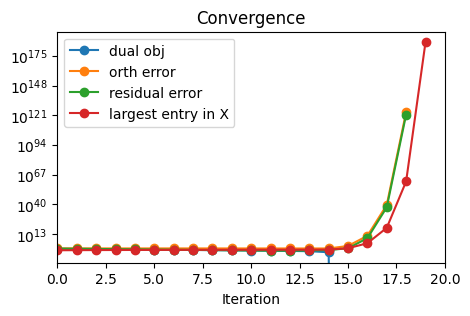

In [3]:
fig, ax = plt.subplots(figsize=(5, 3))

ax.plot(df['dual_obj'], marker='o', label='dual obj')
ax.plot(df['orth_error'], marker='o', label='orth error')
ax.plot(df['residual_error'], marker='o', label='residual error')
ax.plot(df['X_largest_entry'], marker='o', label='largest entry in X')

for restart in PE.restarts:
    ax.axvline(x=restart - 0.5, color='black', linestyle='dashed', linewidth=0.5)

ax.set_title("Convergence")
ax.set_xlabel("Iteration")
ax.set_yscale("log")
ax.set_xlim(0, len(df) - 1)
ax.legend();

In [9]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

spectrum_cpu = spectrum.cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
columns = ['R_eigvals_from_starting_vecs', 'Z_eigvals_from_starting_vecs', 'Q_eigvals_from_starting_vecs', 'X_eigvals_from_starting_vecs']
# columns = ['R_eigvals', 'Z_eigvals', 'Q_eigvals', 'X_eigvals']
titles = ['R eigvals', 'Z eigvals', 'Q eigvals', 'X eigvals']
all_lines = {col: [] for col in columns}

def init():
    ret = []
    for ax, col, title, fun in zip(axes, columns, titles, (lambda x: np.ones_like(x), lambda x: np.ones_like(x), lambda x: 1/x,)):
        line, = ax.plot(spectrum_cpu, fun(spectrum_cpu), color='black', linestyle='dashed', linewidth=0.5)
        all_lines[col].append(line)
        ret.extend(all_lines[col])
    return ret

def update(frame):
    ret = []
    for ax, col, title in zip(axes, columns, titles):
        vals = df[col].iloc[frame]
        line, = ax.plot(spectrum_cpu, vals, label=f'step {frame}')
        all_lines[col].append(line)
        ax.set_title(f'{title} (steps 0 – {frame})')
        ax.set_xlabel('X_0 eigenvalues')
        ax.legend(loc='upper right', fontsize='small')
        ret.extend(all_lines[col])
    return ret

ani = FuncAnimation(fig, update, frames=len(df), init_func=lambda: [], interval=500, repeat=False)
plt.close(fig)
HTML(ani.to_jshtml())